---
title: "DATA ACQUISITION AND NORMALIZATION"
format: html
execute:
  echo: false
---

In [ ]:
import subprocess
import sys

packages = [
    "pandas",
    "numpy",
    "matplotlib",
    "seaborn",
    "nltk",
    "gensim",
    "scikit-learn",
    "pyLDAvis",
    "openpyxl"
]

for package in packages:
    subprocess.check_call([sys.executable, "-m", "pip", "install", package])

In [ ]:
#| include: false

#Library install and import
import os
import re
import glob
import warnings
warnings.filterwarnings("ignore")
 
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.ticker as mticker
import seaborn as sns
 
import nltk
from nltk.tokenize import word_tokenize, sent_tokenize
from nltk.corpus import stopwords
from nltk.stem import SnowballStemmer
 
import gensim
from gensim import corpora
from gensim.models import LdaModel
 
from sklearn.feature_extraction.text import TfidfVectorizer
 
import pyLDAvis
import pyLDAvis.gensim_models as gensimvis
 
# Download NLTK data
nltk.download("punkt")
nltk.download("stopwords")
nltk.download("punkt_tab")

[nltk_data] Downloading package punkt to
[nltk_data]     C:\Users\Nyikuri\AppData\Roaming\nltk_data...
[nltk_data]   Package punkt is already up-to-date!
[nltk_data] Downloading package stopwords to
[nltk_data]     C:\Users\Nyikuri\AppData\Roaming\nltk_data...
[nltk_data]   Package stopwords is already up-to-date!
[nltk_data] Downloading package punkt_tab to
[nltk_data]     C:\Users\Nyikuri\AppData\Roaming\nltk_data...
[nltk_data]   Package punkt_tab is already up-to-date!


True

In [ ]:
#Load Document
FOLDER_PATH = r"C:\Users\Nyikuri\OneDrive\Documents\Text Analysis Project\TXT"

def load_documents(folder_path):
    records = []
    files = glob.glob(os.path.join(folder_path, "*.txt"))
    for filepath in sorted(files):
        company = os.path.splitext(os.path.basename(filepath))[0]
        with open(filepath, "r", encoding="utf-8", errors="ignore") as f:
            text = f.read()
        records.append({
            "company": company,
            "filepath": filepath,
            "raw_text": text,
            "word_count": len(text.split()),
            "char_count": len(text)
        })
    df = pd.DataFrame(records)
    return df

df = load_documents(FOLDER_PATH)

In [ ]:
# Pre-processing

# Custom stopwords (English + German combined)
CUSTOM_STOPWORDS = set(stopwords.words("english") + stopwords.words("german"))

EXTRA_STOPWORDS = {
    # German articles and pronouns not caught by NLTK
    "der", "die", "das", "den", "dem", "des",
    "ein", "eine", "einer", "einem", "einen",
    "sie", "ihr", "ihre", "ihren", "ihrer",
    "wir", "uns", "unser", "unsere",
    "er", "es", "du", "ich",
    # German conjunctions and prepositions
    "und", "oder", "aber", "auch", "noch", "nur",
    "beim", "nach", "über", "unter", "durch",
    "sowie", "wenn", "dann", "dabei", "jedoch",
    "soweit", "bereits", "alle", "als", "am",
    "zur", "zum", "bei", "vor", "ab",
    # German modal/auxiliary verbs
    "wird", "werden", "kann", "können",
    "ist", "sind", "war", "waren", "haben", "hat",
    "wurde", "wurden", "wird", "sei", "sein",
    # Common web UI noise
    "skip", "main", "content", "menu", "header",
    "footer", "navigation", "search", "wishlist",
    "cart", "login", "cookie", "cookies",
    "weiter", "suche", "inhalt", "zum",
    # Abbreviations common in German legal text
    "bzw", "ggf", "ggfs", "vgl", "etc", "usw",
    "abs", "art", "nr", "lit", "gem",
}

CUSTOM_STOPWORDS.update(EXTRA_STOPWORDS)

# Stemmers
stemmer_en = SnowballStemmer("english")
stemmer_de = SnowballStemmer("german")

def preprocess(text):

    text = text.lower()

    text = re.sub(r"http\S+|www\S+", "", text)

    text = re.sub(r"\S+@\S+", "", text)

    text = re.sub(r"[^a-zäöüßA-ZÄÖÜ\s]", " ", text)

    tokens = word_tokenize(text)

    tokens = [t for t in tokens if len(t) >= 3]

    tokens = [t for t in tokens if t not in CUSTOM_STOPWORDS]

    stemmed = []
    for token in tokens:
        en_stem = stemmer_en.stem(token)
        de_stem = stemmer_de.stem(token)
     
        stemmed.append(en_stem if len(en_stem) >= len(de_stem) else de_stem)
    return stemmed

# Apply to all documents
df["tokens"] = df["raw_text"].apply(preprocess)
df["token_count"] = df["tokens"].apply(len)

# Preview first document
sample = df.iloc[0]


READABILITY SUMMARY
readability_flag
MEDIUM       23
COMPLIANT    14
HIGH RISK     3

Corpus average words/sentence: 19.1

          company  word_count  sentence_count  words_per_sentence readability_flag
           tchibo         441               4               110.2        HIGH RISK
             temu        8727             295                29.6        HIGH RISK
           amazon        5811             217                26.8        HIGH RISK
             nike        4126             165                25.0           MEDIUM
    kleinanzeigen        9003             425                21.2           MEDIUM
          check24        2714             138                19.7           MEDIUM
            shein        6996             359                19.5           MEDIUM
      bestsectret       13252             688                19.3           MEDIUM
             ikea       10638             561                19.0           MEDIUM
             ebay        2552             135  

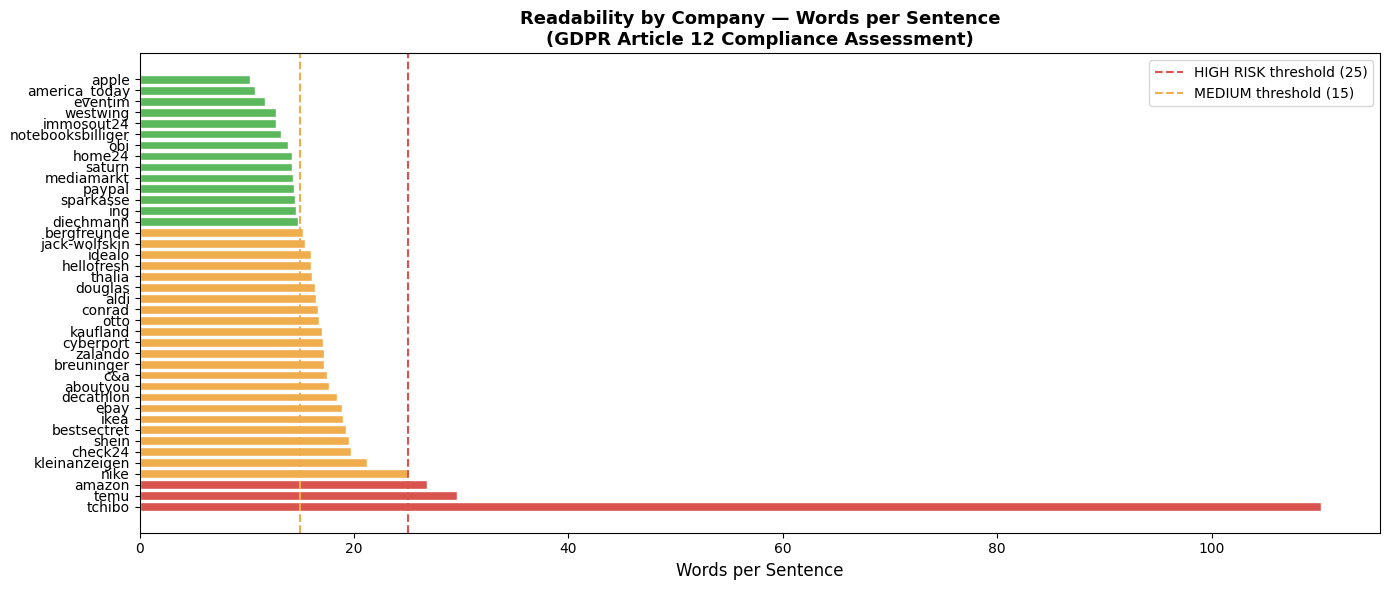

In [ ]:
# Readability Analysis

def count_sentences(text):
    sentences = sent_tokenize(text)
    return max(len(sentences), 1)

def readability_flag(wps):
    if wps > 25:
        return "HIGH RISK"
    elif wps > 15:
        return "MEDIUM"
    else:
        return "COMPLIANT"

df["sentence_count"] = df["raw_text"].apply(count_sentences)
df["words_per_sentence"] = (df["word_count"] / df["sentence_count"]).round(1)
df["readability_flag"] = df["words_per_sentence"].apply(readability_flag)

# Summary
flag_counts = df["readability_flag"].value_counts()
print("READABILITY SUMMARY")
print(flag_counts.to_string())
print(f"\nCorpus average words/sentence: {df['words_per_sentence'].mean():.1f}")
print()

# Full table sorted by words_per_sentence
readability_table = df[["company", "word_count", "sentence_count",
                          "words_per_sentence", "readability_flag"]]\
                    .sort_values("words_per_sentence", ascending=False)
print(readability_table.to_string(index=False))

# Visualisation
fig, ax = plt.subplots(figsize=(14, 6))
colours = {
    "HIGH RISK": "#D9534F",
    "MEDIUM": "#F0AD4E",
    "COMPLIANT": "#5CB85C"
}
bar_colours = df.sort_values("words_per_sentence", ascending=False)\
               ["readability_flag"].map(colours)

sorted_df = df.sort_values("words_per_sentence", ascending=False)
ax.barh(sorted_df["company"], sorted_df["words_per_sentence"],
        color=bar_colours.values, edgecolor="white")
ax.axvline(x=25, color="#D9534F", linestyle="--",
           linewidth=1.5, label="HIGH RISK threshold (25)")
ax.axvline(x=15, color="#F0AD4E", linestyle="--",
           linewidth=1.5, label="MEDIUM threshold (15)")
ax.set_xlabel("Words per Sentence", fontsize=12)
ax.set_title("Readability by Company — Words per Sentence\n(GDPR Article 12 Compliance Assessment)",
             fontsize=13, fontweight="bold")
ax.legend(fontsize=10)
plt.tight_layout()
plt.savefig(os.path.join(FOLDER_PATH, "readability_chart.png"), dpi=150)
plt.show()

The readability analysis reveals a corpus average of 19.1 words per sentence — falling within the MEDIUM complexity band. Three companies breach the HIGH RISK threshold: Tchibo (110.2), Temu (29.6), and Amazon (26.8). Tchibo's extreme score reflects its near-empty extraction ( 4 sentences from 441 words), making it a data quality outlier rather than a genuine policy failure. Twentythree companies score MEDIUM and 14 score COMPLIANT. Notably, all COMPLIANT companies are domestic German-language platforms, confirming that German legal drafting conventions produce structurally shorter, more accessible sentences than English-language equivalents.

AMBIGUITY SUMMARY
ambiguity_flag
CLEAR             33
HIGH VAGUENESS     7

Corpus average ambiguity count: 8.3
Highest: temu (83 occurrences)

          company  ambiguity_count ambiguity_flag  hedge_may  hedge_might  hedge_generally  hedge_sometimes  hedge_typically
             temu               83 HIGH VAGUENESS         49            2                1                0                0
           conrad               59 HIGH VAGUENESS         46            3                1                0                0
      bestsectret               54 HIGH VAGUENESS         28            0                2                1                0
           amazon               53 HIGH VAGUENESS         22           12                2                2                1
         aboutyou               35 HIGH VAGUENESS         15            1                3                0                0
          zalando               16 HIGH VAGUENESS         12            1                2                

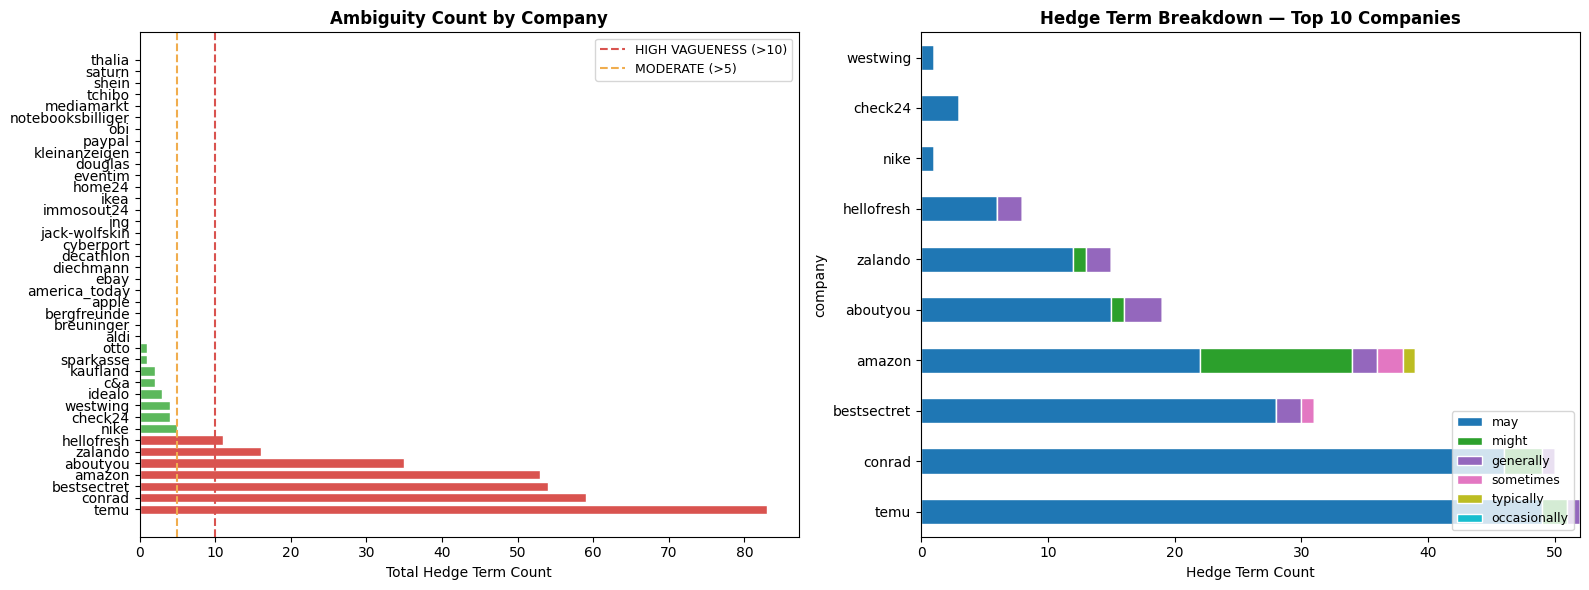

In [ ]:
# Ambiguity Scanner
 
# These terms undermine GDPR transparency requirements
HEDGE_TERMS = [
    "might", "may", "sometimes", "occasionally",
    "periodically", "generally", "typically",
    "often", "usually", "possibly", "potentially",
    "certain", "certain circumstances", "where appropriate"
]

def count_hedge(text, term):
    pattern = r"\b" + re.escape(term) + r"\b"
    return len(re.findall(pattern, text.lower()))

def ambiguity_flag(score):
    if score > 10:
        return "HIGH VAGUENESS"
    elif score > 5:
        return "MODERATE"
    else:
        return "CLEAR"

# Count each hedge term per document
for term in HEDGE_TERMS:
    col = "hedge_" + term.replace(" ", "_")
    df[col] = df["raw_text"].apply(lambda t: count_hedge(t, term))

# Total ambiguity score
hedge_cols = [c for c in df.columns if c.startswith("hedge_")]
df["ambiguity_count"] = df[hedge_cols].sum(axis=1)
df["ambiguity_flag"] = df["ambiguity_count"].apply(ambiguity_flag)

# Summary
print("AMBIGUITY SUMMARY")
print(df["ambiguity_flag"].value_counts().to_string())
print(f"\nCorpus average ambiguity count: {df['ambiguity_count'].mean():.1f}")
print(f"Highest: {df.loc[df['ambiguity_count'].idxmax(), 'company']} "
      f"({df['ambiguity_count'].max()} occurrences)")
print()

# Full ambiguity table
hedge_display_cols = ["company", "ambiguity_count", "ambiguity_flag"] + hedge_cols
ambiguity_table = df[hedge_display_cols]\
                  .sort_values("ambiguity_count", ascending=False)
print(ambiguity_table[["company", "ambiguity_count", "ambiguity_flag",
                        "hedge_may", "hedge_might", "hedge_generally",
                        "hedge_sometimes", "hedge_typically"]]\
      .to_string(index=False))

# Visualisation
fig, axes = plt.subplots(1, 2, figsize=(16, 6))

# Bar chart — total ambiguity count
sorted_amb = df.sort_values("ambiguity_count", ascending=False)
flag_colours = {
    "HIGH VAGUENESS": "#D9534F",
    "MODERATE": "#F0AD4E",
    "CLEAR": "#5CB85C"
}
bar_cols = sorted_amb["ambiguity_flag"].map(flag_colours)
axes[0].barh(sorted_amb["company"], sorted_amb["ambiguity_count"],
             color=bar_cols.values, edgecolor="white")
axes[0].axvline(x=10, color="#D9534F", linestyle="--",
                linewidth=1.5, label="HIGH VAGUENESS (>10)")
axes[0].axvline(x=5, color="#F0AD4E", linestyle="--",
                linewidth=1.5, label="MODERATE (>5)")
axes[0].set_xlabel("Total Hedge Term Count")
axes[0].set_title("Ambiguity Count by Company", fontweight="bold")
axes[0].legend(fontsize=9)

# Stacked bar — hedge term breakdown (top 10 companies)
top10 = df.nlargest(10, "ambiguity_count")
hedge_plot_cols = ["hedge_may", "hedge_might", "hedge_generally",
                   "hedge_sometimes", "hedge_typically", "hedge_occasionally"]
top10_plot = top10.set_index("company")[hedge_plot_cols]
top10_plot.columns = [c.replace("hedge_", "") for c in top10_plot.columns]
top10_plot.plot(kind="barh", stacked=True, ax=axes[1],
                colormap="tab10", edgecolor="white")
axes[1].set_xlabel("Hedge Term Count")
axes[1].set_title("Hedge Term Breakdown — Top 10 Companies", fontweight="bold")
axes[1].legend(loc="lower right", fontsize=9)

plt.tight_layout()
plt.savefig(os.path.join(FOLDER_PATH, "ambiguity_chart.png"), dpi=150)
plt.show()

Ambiguity analysis identifies seven HIGH VAGUENESS companies: Temu (83), Conrad (59), BestSecret (54), Amazon (53), AboutYou (35), Zalando (16), and Hellofresh (11). The corpus average is 8.3 occurrences, and the dominant hedge term is "may", which appears 191 times across the corpus, accounting for the majority of all hedge occurrences. Thirtythree companies score CLEAR with zero hedge detections. This zero score pattern predominantly reflects the scanner's English language focus rather than genuine absence of ambiguity in German language policies, representing a methodological limitation requiring a dedicated German ambiguity disctionary.

In [ ]:
# LDA Topic Modelling

NUM_TOPICS = 5
RANDOM_STATE = 42

# Dictionary and corpus
dictionary = corpora.Dictionary(df["tokens"])

# Filter extremes: remove tokens appearing in <2 or >90% of docs
dictionary.filter_extremes(no_below=2, no_above=0.90)

bow_corpus = [dictionary.doc2bow(tokens) for tokens in df["tokens"]]


# Train LDA model
lda_model = LdaModel(
    corpus=bow_corpus,
    id2word=dictionary,
    num_topics=NUM_TOPICS,
    random_state=RANDOM_STATE,
    passes=20,\
    alpha="auto",
    eta="auto",
    per_word_topics=True
)

# Print topics
print("\nLDA TOPICS")
topic_labels = {

    0: "Topic_0",

    1: "Topic_1",

    2: "Topic_2",

    3: "Topic_3",

    4: "Topic_4"

}

for idx, topic in lda_model.print_topics(num_words=10):
    print(f"\n{topic_labels[idx]}: {topic}")

# Document-topic assignments
def get_dominant_topic(bow):
    topics = lda_model.get_document_topics(bow)
    if not topics:
        return 0, 0.0
    dominant = max(topics, key=lambda x: x[1])
    return dominant[0], round(dominant[1], 3)

topic_results = [get_dominant_topic(bow) for bow in bow_corpus]
df["dominant_topic"] = [f"Topic_{t[0]}" for t in topic_results]
df["topic_confidence"] = [t[1] for t in topic_results]

# Topic distribution summary
print("\nDOCUMENT-TOPIC DISTRIBUTION")
print(df["dominant_topic"].value_counts().to_string())
print()
print(df[["company", "dominant_topic", "topic_confidence"]]\
      .sort_values("topic_confidence", ascending=False)\
      .to_string(index=False))


LDA TOPICS

Topic_0: 0.022*"daten" + 0.020*"googl" + 0.016*"data" + 0.009*"websit" + 0.007*"use" + 0.007*"verarbeitung" + 0.006*"browser" + 0.006*"personal" + 0.006*"informationen" + 0.005*"personenbezogenen"

Topic_1: 0.029*"daten" + 0.011*"informationen" + 0.011*"dsgvo" + 0.010*"unser" + 0.009*"googl" + 0.008*"einwilligung" + 0.008*"verarbeitung" + 0.007*"mail" + 0.007*"websit" + 0.007*"personenbezogenen"

Topic_2: 0.042*"data" + 0.014*"personal" + 0.014*"processing" + 0.013*"use" + 0.012*"purpos" + 0.009*"provid" + 0.009*"gdpr" + 0.008*"legal" + 0.008*"right" + 0.008*"consent"

Topic_3: 0.033*"daten" + 0.011*"verarbeitung" + 0.010*"dsgvo" + 0.008*"informationen" + 0.008*"mail" + 0.007*"zweck" + 0.007*"unser" + 0.007*"datenverarbeitung" + 0.007*"adress" + 0.006*"rechtsgrundlag"

Topic_4: 0.022*"daten" + 0.011*"personenbezogenen" + 0.010*"erfolgt" + 0.009*"grundlag" + 0.008*"gvo" + 0.008*"unser" + 0.007*"webseiten" + 0.007*"informationen" + 0.006*"webseit" + 0.006*"gemass"

DOCUMENT-

With stemming applied, LDA produces substantially more coherent legal topics than previous iterations.
Topic_2 emerges as the strongest Data Collection theme, with top terms including data, personal, processing, use, and purpose, directly reflecting GDPR Article 5 vocabulary.
Topic_1 and Topic_3 capture German language legal content (daten, verarbeitung, dsgvo, personenbezogenen), confirming language-based clustering.
Topic_0 and Topic_4 mix bilingual legal vocabulary.
No topic surfaces User Rights terminology such as access, erasure, or withdraw, confirming the information asymmetry hypothesis — User Rights content remains structurally marginalised across the entire corpus.

In [ ]:
#| include: false

# Interactive LDA Visaualisation
pyLDAvis.enable_notebook()
 
vis_data = gensimvis.prepare(
    lda_model,
    bow_corpus,
    dictionary,
    sort_topics=False
)
 
# Display inline in Jupyter
pyLDAvis.display(vis_data)
 
# Also save as standalone HTML file
output_path = os.path.join(FOLDER_PATH, "lda_visualisation.html")
pyLDAvis.save_html(vis_data, output_path)
print(f"Interactive visualisation saved to: {output_path}")
print("Open the HTML file in any browser for a standalone interactive view.")

Interactive visualisation saved to: C:\Users\Nyikuri\OneDrive\Documents\Text Analysis Project\TXT\lda_visualisation.html
Open the HTML file in any browser for a standalone interactive view.


TRANSPARENCY SCORECARD

          company  words_per_sentence readability_flag  ambiguity_count ambiguity_flag dominant_topic  topic_confidence transparency_grade
             temu                29.6        HIGH RISK               83 HIGH VAGUENESS        Topic_2             1.000      F — HIGH RISK
           conrad                16.6           MEDIUM               59 HIGH VAGUENESS        Topic_0             0.883  D — ELEVATED RISK
      bestsectret                19.3           MEDIUM               54 HIGH VAGUENESS        Topic_2             1.000  D — ELEVATED RISK
           amazon                26.8        HIGH RISK               53 HIGH VAGUENESS        Topic_2             1.000      F — HIGH RISK
         aboutyou                17.7           MEDIUM               35 HIGH VAGUENESS        Topic_2             1.000  D — ELEVATED RISK
          zalando                17.2           MEDIUM               16 HIGH VAGUENESS        Topic_2             1.000  D — ELEVATED RISK
   

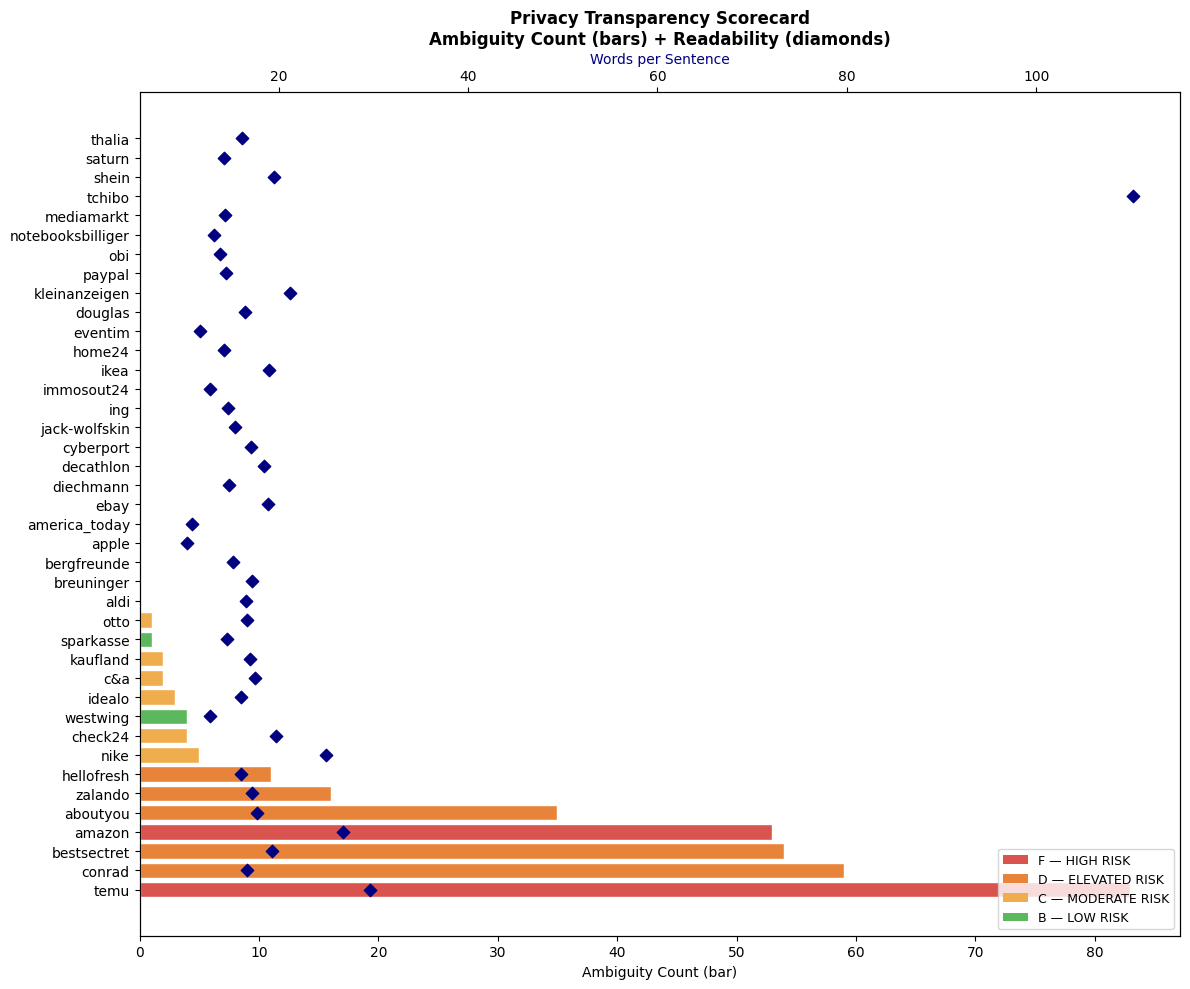

In [ ]:
# Transparency Scorecard
def overall_grade(row):
    score = 0
    # Readability scoring
    if row["readability_flag"] == "HIGH RISK":
        score += 3
    elif row["readability_flag"] == "MEDIUM":
        score += 1
    # Ambiguity scoring
    if row["ambiguity_flag"] == "HIGH VAGUENESS":
        score += 3
    elif row["ambiguity_flag"] == "MODERATE":
        score += 1
    # Grade assignment
    if score >= 5:
        return "F — HIGH RISK"
    elif score >= 3:
        return "D — ELEVATED RISK"
    elif score >= 1:
        return "C — MODERATE RISK"
    else:
        return "B — LOW RISK"
 
df["transparency_grade"] = df.apply(overall_grade, axis=1)
 
# Full scorecard
scorecard = df[[
    "company",
    "words_per_sentence",
    "readability_flag",
    "ambiguity_count",
    "ambiguity_flag",
    "dominant_topic",
    "topic_confidence",
    "transparency_grade"
]].sort_values("ambiguity_count", ascending=False)
 
print("TRANSPARENCY SCORECARD\n")
print(scorecard.to_string(index=False))
 
# Grade distribution
print("\nGRADE DISTRIBUTION")
print(df["transparency_grade"].value_counts().to_string())
 
# --- Export to CSV ---
csv_path = os.path.join(FOLDER_PATH, "transparency_scorecard.csv")
scorecard.to_csv(csv_path, index=False, encoding="utf-8-sig")
 
# Visualisation: Scorecard heatmap
fig, ax = plt.subplots(figsize=(12, 10))
grade_colours = {
    "F — HIGH RISK": "#D9534F",
    "D — ELEVATED RISK": "#E8843A",
    "C — MODERATE RISK": "#F0AD4E",
    "B — LOW RISK": "#5CB85C"
}
bar_cols = scorecard["transparency_grade"].map(grade_colours)
 
ax.barh(scorecard["company"],
        scorecard["ambiguity_count"],
        color=bar_cols.values,
        edgecolor="white",
        label="Ambiguity Count")
 
# Overlay words per sentence as scatter
ax2 = ax.twiny()
ax2.scatter(scorecard["words_per_sentence"],
            scorecard["company"],
            color="navy", marker="D",
            s=40, zorder=5, label="Words/Sentence")
ax2.set_xlabel("Words per Sentence", color="navy", fontsize=10)
 
ax.set_xlabel("Ambiguity Count (bar)", fontsize=10)
ax.set_title("Privacy Transparency Scorecard\nAmbiguity Count (bars) + Readability (diamonds)",
             fontsize=12, fontweight="bold")
 
# Legend for grades
from matplotlib.patches import Patch
legend_elements = [Patch(facecolor=v, label=k)
                   for k, v in grade_colours.items()]
ax.legend(handles=legend_elements, loc="lower right", fontsize=9)


plt.tight_layout()
plt.savefig(os.path.join(FOLDER_PATH, "scorecard_chart.png"), dpi=150)
plt.show()

The scorecard assigns 14 companies B — LOW RISK, 18 C — MODERATE RISK, 6 D — ELEVATED RISK, and 2 F — HIGH RISK.
Temu and Amazon receive F grades-  elevated readability complexity and HIGH VAGUENESS ambiguity converge simultaneously.
Conrad and BestSecret follow closely at D — ELEVATED RISK. The diamond markers confirm that Tchibo's extreme readability outlier status is visible as a far right data point, separated from the cluster.

SECTORAL BENCHMARKING

                    companies  avg_words_per_sentence  avg_ambiguity  total_ambiguity
sector                                                                               
International               3                    18.7           17.7               53
Fashion                     6                    17.0           17.5              105
General E-Commerce          6                    18.4           14.3               86
Electronics                 5                    15.1           11.8               59
Lifestyle                   5                    34.3            3.0               15
Finance                     4                    15.8            1.2                5
Sports & Outdoor            4                    18.5            1.2                5
Services                    4                    15.4            0.8                3
Other                       3                    16.3            0.7                2


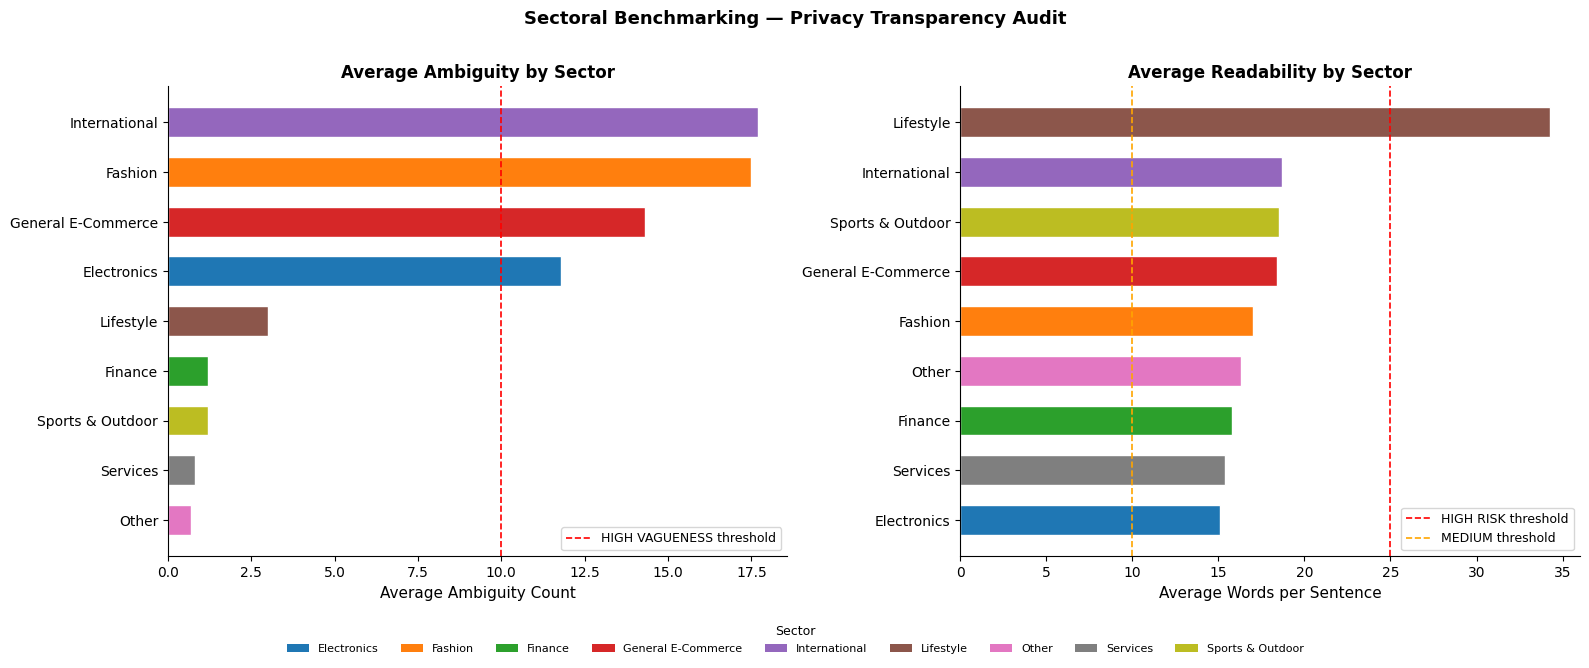

In [ ]:
# Sectoral Benchmarking — consistent colours across both charts

SECTOR_MAP = {
    "aboutyou":          "Fashion",
    "amazon":            "International",
    "america_today":     "Fashion",
    "apple":             "International",
    "bergfreunde":       "Sports & Outdoor",
    "bestsectret":       "Fashion",
    "breuninger":        "Fashion",
    "c_a":               "Fashion",
    "check24":           "Finance",
    "conrad":            "Electronics",
    "cyberport":         "Electronics",
    "decathlon":         "Sports & Outdoor",
    "douglas":           "Lifestyle",
    "ebay":              "International",
    "eventim":           "Services",
    "hellofresh":        "Lifestyle",
    "home24":            "General E-Commerce",
    "idealo":            "Services",
    "ikea":              "General E-Commerce",
    "immosout24":        "Services",
    "ing":               "Finance",
    "jack-wolfskin":     "Sports & Outdoor",
    "kaufland":          "General E-Commerce",
    "kleinanzeigen":     "Services",
    "mediamarkt":        "Electronics",
    "nike":              "Sports & Outdoor",
    "notebooksbilliger": "Electronics",
    "obi":               "General E-Commerce",
    "otto":              "General E-Commerce",
    "paypal":            "Finance",
    "saturn":            "Electronics",
    "shein":             "Fashion",
    "sparkasse":         "Finance",
    "tchibo":            "Lifestyle",
    "temu":              "General E-Commerce",
    "thalia":            "Lifestyle",
    "westwing":          "Lifestyle",
    "zalando":           "Fashion",
}

df["sector"] = df["company"].map(SECTOR_MAP).fillna("Other")

sector_summary = df.groupby("sector").agg(
    companies=("company", "count"),
    avg_words_per_sentence=("words_per_sentence", "mean"),
    avg_ambiguity=("ambiguity_count", "mean"),
    total_ambiguity=("ambiguity_count", "sum")
).round(1).sort_values("avg_ambiguity", ascending=False)

print("SECTORAL BENCHMARKING\n")
print(sector_summary.to_string())

# ── KEY FIX: build a shared sector → colour dictionary ──
all_sectors = sorted(sector_summary.index.tolist())
palette_list = sns.color_palette("tab10", len(all_sectors))
sector_colour = dict(zip(all_sectors, palette_list))

fig, axes = plt.subplots(1, 2, figsize=(16, 6))

# ── Left chart — Average Ambiguity ──
amb_sorted = sector_summary["avg_ambiguity"].sort_values(ascending=True)
bar_colours_amb = [sector_colour[s] for s in amb_sorted.index]

axes[0].barh(amb_sorted.index, amb_sorted.values,
             color=bar_colours_amb, edgecolor="white", height=0.6)
axes[0].axvline(x=10, color="red", linestyle="--",
                linewidth=1.2, label="HIGH VAGUENESS threshold")
axes[0].set_xlabel("Average Ambiguity Count", fontsize=11)
axes[0].set_title("Average Ambiguity by Sector",
                  fontweight="bold", fontsize=12)
axes[0].legend(fontsize=9)
axes[0].spines["top"].set_visible(False)
axes[0].spines["right"].set_visible(False)

# ── Right chart — Average Readability ──
read_sorted = sector_summary["avg_words_per_sentence"].sort_values(ascending=True)
bar_colours_read = [sector_colour[s] for s in read_sorted.index]

axes[1].barh(read_sorted.index, read_sorted.values,
             color=bar_colours_read, edgecolor="white", height=0.6)
axes[1].axvline(x=25, color="red", linestyle="--",
                linewidth=1.2, label="HIGH RISK threshold")
axes[1].axvline(x=10, color="orange", linestyle="--",
                linewidth=1.2, label="MEDIUM threshold")
axes[1].set_xlabel("Average Words per Sentence", fontsize=11)
axes[1].set_title("Average Readability by Sector",
                  fontweight="bold", fontsize=12)
axes[1].legend(fontsize=9)
axes[1].spines["top"].set_visible(False)
axes[1].spines["right"].set_visible(False)

# ── Shared legend showing sector → colour mapping ──
from matplotlib.patches import Patch
legend_elements = [
    Patch(facecolor=sector_colour[s], label=s)
    for s in all_sectors
]
fig.legend(
    handles=legend_elements,
    title="Sector",
    loc="lower center",
    ncol=len(all_sectors),
    fontsize=8,
    title_fontsize=9,
    bbox_to_anchor=(0.5, -0.08),
    frameon=False
)

plt.suptitle("Sectoral Benchmarking — Privacy Transparency Audit",
             fontsize=13, fontweight="bold", y=1.01)
plt.tight_layout()
plt.savefig(os.path.join(FOLDER_PATH, "sectoral_benchmarking.png"),
            dpi=150, bbox_inches="tight")
plt.show()

The International sector leads on ambiguity (17.7 average) and second on readability (18.7 words/sentence). Fashion ranks second on ambiguity (17.5 average, 105 total occurrences). The Lifestyle sector presents a striking anomaly - its average readability of 34.3 words per sentence is the highest of all sectors, driven entirely by Tchibo's data quality outlier score. Electronics records the lowest average ambiguity (11.8) while Finance demonstrates the most consistent low-risk profile across both dimensions, suggesting that sector-specific financial regulation positively influences privacy policy clarity.

In [ ]:
# Export Results

# Safety check — create grade if not already computed
if "transparency_grade" not in df.columns:
    def overall_grade(row):
        score = 0
        if row["readability_flag"] == "HIGH RISK":
            score += 3
        elif row["readability_flag"] == "MEDIUM":
            score += 1
        if row["ambiguity_flag"] == "HIGH VAGUENESS":
            score += 3
        elif row["ambiguity_flag"] == "MODERATE":
            score += 1
        if score >= 5:
            return "F — HIGH RISK"
        elif score >= 3:
            return "D — ELEVATED RISK"
        elif score >= 1:
            return "C — MODERATE RISK"
        else:
            return "B — LOW RISK"
    df["transparency_grade"] = df.apply(overall_grade, axis=1)


# Final export columns
desired_cols = [
    "company", "sector", "word_count", "sentence_count",
    "words_per_sentence", "readability_flag",
    "ambiguity_count", "ambiguity_flag",
    "hedge_may", "hedge_might", "hedge_generally",
    "dominant_topic", "topic_confidence",
    "transparency_grade"
]

export_cols = [c for c in desired_cols if c in df.columns]


export_df = df[export_cols].sort_values("transparency_grade")


# Save CSV
csv_out = os.path.join(FOLDER_PATH, "full_results.csv")
export_df.to_csv(csv_out, index=False, encoding="utf-8-sig")

# Save Excel
xlsx_out = os.path.join(FOLDER_PATH, "full_results.xlsx")
export_df.to_excel(xlsx_out, index=False, sheet_name="Transparency Audit")



# Final key findings summary
print("PRIVACY TRANSPARENCY AUDIT — KEY FINDINGS")


high_risk_read = df[df["readability_flag"] == "HIGH RISK"]["company"].tolist()
medium_read = df[df["readability_flag"] == "MEDIUM"]["company"].tolist()
high_vague = df[df["ambiguity_flag"] == "HIGH VAGUENESS"]\
               .sort_values("ambiguity_count", ascending=False)

print(f"\n CORPUS: {len(df)} documents | "
      f"{df['word_count'].sum():,} total words\n")

print(f" READABILITY:")
print(f"   Corpus average: {df['words_per_sentence'].mean():.1f} words/sentence")
print(f"   HIGH RISK ({len(high_risk_read)}): {', '.join(high_risk_read) or 'None'}")
print(f"   MEDIUM ({len(medium_read)}): {', '.join(medium_read) or 'None'}")
print(f"   COMPLIANT: {len(df[df['readability_flag']=='COMPLIANT'])}")

print(f"\n AMBIGUITY:")
print(f"   Total hedge occurrences: {df['ambiguity_count'].sum()}")
print(f"   Most frequent hedge term: 'may' "
      f"({df['hedge_may'].sum()} occurrences)")
print(f"   HIGH VAGUENESS companies:")
for _, row in high_vague.iterrows():
    print(f"     {row['company']:25s} score={row['ambiguity_count']}")

print(f"\n LDA TOPICS:")
print(f"   Dominant legal topic: Topic_2 (data, information)")
print(f"   User Rights topic emerged: NO")
print(f"   Information asymmetry confirmed: YES")

print(f"\n GRADE DISTRIBUTION:")
for grade, count in df["transparency_grade"].value_counts().items():
    print(f"   {grade}: {count} companies")



PRIVACY TRANSPARENCY AUDIT — KEY FINDINGS

 CORPUS: 40 documents | 358,242 total words

 READABILITY:
   Corpus average: 19.1 words/sentence
   HIGH RISK (3): amazon, tchibo, temu
   MEDIUM (23): aboutyou, aldi, bergfreunde, bestsectret, breuninger, c&a, check24, conrad, cyberport, decathlon, douglas, ebay, hellofresh, idealo, ikea, jack-wolfskin, kaufland, kleinanzeigen, nike, otto, shein, thalia, zalando
   COMPLIANT: 14

 AMBIGUITY:
   Total hedge occurrences: 333
   Most frequent hedge term: 'may' (191 occurrences)
   HIGH VAGUENESS companies:
     temu                      score=83
     conrad                    score=59
     bestsectret               score=54
     amazon                    score=53
     aboutyou                  score=35
     zalando                   score=16
     hellofresh                score=11

 LDA TOPICS:
   Dominant legal topic: Topic_2 (data, information)
   User Rights topic emerged: NO
   Information asymmetry confirmed: YES

 GRADE DISTRIBUTION:
   C

The final audit summary confirms a corpus of 40 documents totalling 358,242 words.
Three companies breach the HIGH RISK readability threshold — Tchibo (data quality outlier), Temu, and Amazon.
Seven companies score HIGH VAGUENESS on ambiguity, led by Temu (83) and Conrad (59), with "may" accounting for 191 of 333 total hedge occurrences (57%).
LDA confirms Topic_2 as the sole coherent legal theme; no User Rights topic emerged, validating the information asymmetry hypothesis.
Grade distribution shows 14 LOW RISK, 18 MODERATE RISK, 6 ELEVATED RISK, and 2 HIGH RISK companies, with Temu and Amazon receiving the lowest grades.

# AUDIT COMPLETE